Notebook used to validate and conduct basic analysis on STRING PPI data of RV.

### Imports

In [25]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt

# choose files
raw_file = '../data/1_raw/string_ppi/rv_ppi.txt'
processed_file = '../data/3_organized/processed_rv_ppi.tsv'
merge_ids_tsv = '../data/2_merged/merged_RV.tsv'

# checks
scores_within_range_check = False
processing_count_check = False
num_unique_ids_check = False
missing_ids_check = False

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/keitaichii/Programming/RESEARCH/TORII/tardigrade_proteome_KG/notebooks


### Data Read-In

In [26]:
# convert raw file to df
raw_df = pd.read_csv(raw_file, sep=' ')
print("Raw DataFrame head:")
print(raw_df.head())

Raw DataFrame head:
            protein1           protein2  combined_score
0  947166.A0A0E3VIU6  947166.A0A1D1UQ43             177
1  947166.A0A0E3VIU6  947166.A0A1D1UB79             263
2  947166.A0A0E3VIU6  947166.A0A1D1VZ17             193
3  947166.A0A0E3VIU6  947166.A0A1D1V4Q1             344
4  947166.A0A0E3VIU6  947166.A0A1D1UVI9             179


In [27]:
# convert processed file to df
processed_df = pd.read_csv(processed_file, sep='\t')
print("Processed DataFrame head:")
print(processed_df.head())

Processed DataFrame head:
   PPI_source  PPI_target  score
0  A0A0E3VIU6  A0A1D1VFY2  0.472
1  A0A0E3VIU6  A0A1D1VZM7  0.641
2  A0A0E3VIU6  A0A1D1V4J8  0.422
3  A0A0E3VIU6  A0A1D1V0Z2  0.539
4  A0A0E3VIU6  A0A1D1UP71  0.400


### Checking Filtering

In [28]:
# confirm that scores are within expected range (0 to 1000) in raw
if raw_df['combined_score'].between(0, 1000).all():
    print("All combined scores in raw data are within the expected range (0 to 1000).")
else:
    print("Warning: Some combined scores in raw data are outside the expected range (0 to 1000).")

All combined scores in raw data are within the expected range (0 to 1000).


In [29]:
# check filters (removal of low confidence (score < 400))
confidence_threshold = 0.400
# confirm that all scores in processed_df are >= threshold
if (processed_df['score'] >= confidence_threshold).all():
    print(f"All interactions in processed DataFrame meet the confidence threshold of {confidence_threshold}.")
else:
    print("Some interactions in processed DataFrame do not meet the confidence threshold.")
# confirm that scores are within expected range (0 to 1) in processed
if processed_df['score'].between(0, 1).all():
    print("All combined scores in processed DataFrame are within the expected range (0 to 1).")
else:
    print("Some combined scores in processed DataFrame are outside the expected range (0 to 1).")

# if both checks passed
if (processed_df['score'] >= confidence_threshold).all() and processed_df['score'].between(0, 1).all():
    scores_within_range_check = True

All interactions in processed DataFrame meet the confidence threshold of 0.4.
All combined scores in processed DataFrame are within the expected range (0 to 1).


In [30]:
# change in the number of entries from raw to processed
raw_count = raw_df.shape[0]
processed_count = processed_df.shape[0]
print(f"Number of interactions in raw data: {raw_count}")
print(f"Number of interactions in processed data: {processed_count}")
print()
print(f"Number of interactions removed during processing: {raw_count - processed_count}")
print(f"Number of interactions less than confidence in raw ({confidence_threshold}): {raw_df[raw_df['combined_score'] < confidence_threshold * 1000].shape[0]}")

if raw_count - processed_count == raw_df[raw_df['combined_score'] < confidence_threshold * 1000].shape[0]:
    print("The reduction in the number of interactions is consistent with the confidence filter applied.")
    processing_count_check = True

Number of interactions in raw data: 12063614
Number of interactions in processed data: 1942258

Number of interactions removed during processing: 10121356
Number of interactions less than confidence in raw (0.4): 10121356
The reduction in the number of interactions is consistent with the confidence filter applied.


Text(0, 0.5, 'Occurrences (Count)')

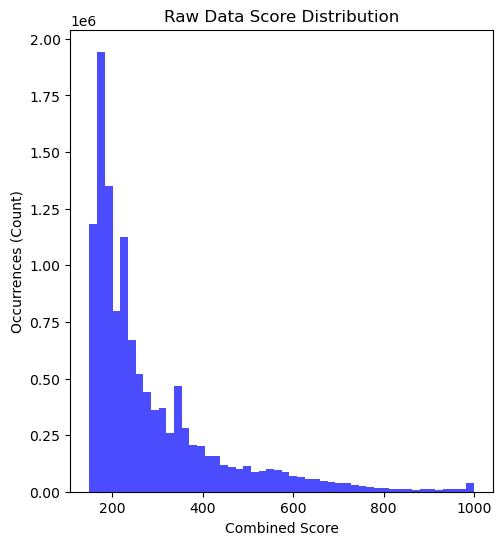

In [31]:
# visualize raw score distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(raw_df['combined_score'], bins=50, color='blue', alpha=0.7)
plt.title('Raw Data Score Distribution')
plt.xlabel('Combined Score')
plt.ylabel('Occurrences (Count)')


Text(0, 0.5, 'Occurrences (Count)')

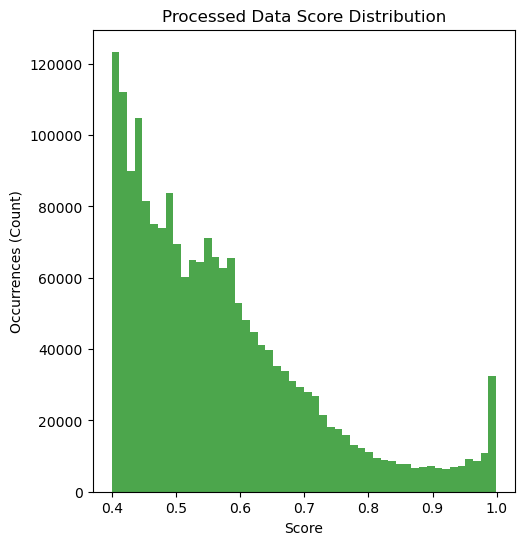

In [32]:
# visualize processed score distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(processed_df['score'], bins=50, color='green', alpha=0.7)
plt.title('Processed Data Score Distribution')
plt.xlabel('Score')
plt.ylabel('Occurrences (Count)')

### Checking ID Processing

In [33]:
# checking that the ID processing is not causing IDs to be lost.
print(f"Number of Unique IDs in Raw Data: {len(set(raw_df['protein1']).union(set(raw_df['protein2'])))}")
print(f"Number of Unique IDs in Raw that Meet Confidence Threshold: {len(set(raw_df[raw_df['combined_score'] >= confidence_threshold * 1000]['protein1']).union(set(raw_df[raw_df['combined_score'] >= confidence_threshold * 1000]['protein2'])))}")
print()
print(f"Number of Unique IDs in Processed Data: {len(set(processed_df['PPI_source']).union(set(processed_df['PPI_target'])))}")

if len(set(processed_df['PPI_source']).union(set(processed_df['PPI_target']))) <= len(set(raw_df[raw_df['combined_score'] >= confidence_threshold * 1000]['protein1']).union(set(raw_df[raw_df['combined_score'] >= confidence_threshold * 1000]['protein2']))):
    print("No required unique IDs were lost during processing.")
    num_unique_ids_check = True

Number of Unique IDs in Raw Data: 11671
Number of Unique IDs in Raw that Meet Confidence Threshold: 11050

Number of Unique IDs in Processed Data: 11050
No required unique IDs were lost during processing.


In [34]:
# checking how many unique IDs do not match anything in our KG dataset
KG_ids_file = '../data/3_organized/info_RV_UniProt_ID.tsv'
kg_ids_df = pd.read_csv(KG_ids_file, sep='\t')
kg_ids_set = set(kg_ids_df['UniProt_ID'])

processed_ids_set = set(processed_df['PPI_source']).union(set(processed_df['PPI_target']))

processed_ids_not_in_kg = processed_ids_set - kg_ids_set
kg_ids_not_in_processed = kg_ids_set - processed_ids_set

print(f"Number of KG Unique IDs: {len(kg_ids_set)}")
print(f"Number of Unique IDs in Processed Data not in KG: {len(processed_ids_not_in_kg)} ({len(processed_ids_not_in_kg)/len(processed_ids_set)*100:.2f}%)")
print(f"Number of Unique IDs in KG not in Processed Data: {len(kg_ids_not_in_processed)} ({len(kg_ids_not_in_processed)/len(kg_ids_set)*100:.2f}%)")

Number of KG Unique IDs: 22416
Number of Unique IDs in Processed Data not in KG: 267 (2.42%)
Number of Unique IDs in KG not in Processed Data: 11633 (51.90%)


In [35]:
merge_ids_df = pd.read_csv(merge_ids_tsv, sep='\t')
merge_ids_set = set(merge_ids_df['Other_IDs'].dropna().str.split(';').sum())

print(f"Number of Unique IDs in Merged Data: {len(merge_ids_set)}")
print(f"Number of Unique IDs in Processed Data and Merged Data: {len(processed_ids_set.intersection(merge_ids_set))}")
print(f"Number of Processed/Merged IDs not in KG: {len((processed_ids_set.intersection(merge_ids_set)) - kg_ids_set)}")

Number of Unique IDs in Merged Data: 1118
Number of Unique IDs in Processed Data and Merged Data: 267
Number of Processed/Merged IDs not in KG: 267


In [36]:
print(f"Number of Missing KG Proteins not due to Merge: {len(processed_ids_not_in_kg - (processed_ids_set.intersection(merge_ids_set)))}")
print(f"IDs of the Missing KG Proteins: {processed_ids_not_in_kg - (processed_ids_set.intersection(merge_ids_set))}")

if len(processed_ids_not_in_kg - (processed_ids_set.intersection(merge_ids_set))) == 0:
    print("All missing KG IDs can be accounted for by the merge process.")
    missing_ids_check = True

Number of Missing KG Proteins not due to Merge: 0
IDs of the Missing KG Proteins: set()
All missing KG IDs can be accounted for by the merge process.


In [37]:
# show all checks
print("\nSummary of Validation Checks:")
print(f"1. Scores Within Range Check: {'Passed' if scores_within_range_check else 'Failed'}")
print(f"2. Processing Count Check: {'Passed' if processing_count_check else 'Failed'}")
print(f"3. Unique IDs Preservation Check: {'Passed' if num_unique_ids_check else 'Failed'}")
print(f"4. Missing KG IDs Check: {'Passed' if missing_ids_check else 'Failed'}")


Summary of Validation Checks:
1. Scores Within Range Check: Passed
2. Processing Count Check: Passed
3. Unique IDs Preservation Check: Passed
4. Missing KG IDs Check: Passed
